## step 1 import all required libraries

In [ ]:
# Import Required Libraries
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt


## STEP 2 — Load and Explore the MNIST Dataset

In [ ]:
from tensorflow.keras.datasets import mnist

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# cheek the sahpe of the dataset
print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test images shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


In [ ]:
import pandas as pd

pd.DataFrame(x_train[0]) # extract pexil value of the first digit

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,175,26,166,255,247,127,0,0,0,0
6,0,0,0,0,0,0,0,0,30,36,...,225,172,253,242,195,64,0,0,0,0
7,0,0,0,0,0,0,0,49,238,253,...,93,82,82,56,39,0,0,0,0,0
8,0,0,0,0,0,0,0,18,219,253,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,80,156,...,0,0,0,0,0,0,0,0,0,0


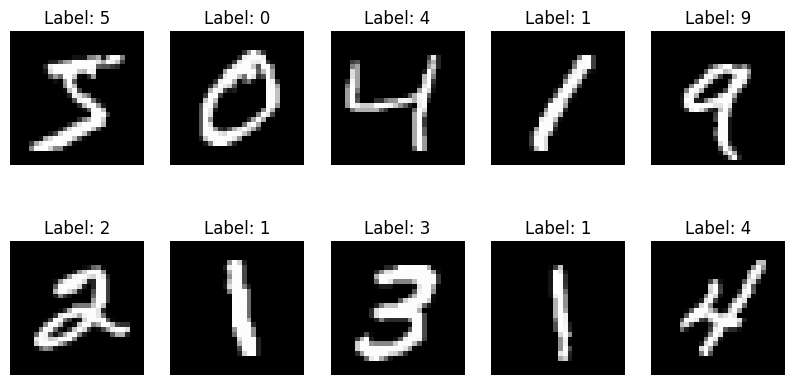

In [ ]:
# Visualize Some Sample Images

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title("Label: " + str(y_train[i]))
    plt.axis('off')

plt.show() # This will display 10 sample handwritten digits with their correct labels.


In [ ]:
# Quick Label Check
print("First 10 labels:", y_train[:10])



First 10 labels: [5 0 4 1 9 2 1 3 1 4]


## STEP 3 — Data Preprocessing

In [ ]:
# Normalize Pixel Values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [ ]:
print(x_train[0][18]) # cheek normalization of pixel

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.18039216 0.50980395 0.7176471  0.99215686
 0.99215686 0.8117647  0.00784314 0.         0.         0.
 0.         0.         0.         0.        ]


 ## reshaping image for CNN

---




In [ ]:

x_train = x_train.reshape(-1, 28, 28, 1) # -1 automatically calculate the sample dataset
x_test = x_test.reshape(-1, 28, 28, 1)

-1 → automatically calculates the number of samples (60,000 for train)

28, 28 → image height and width

1 → number of channels (grayscale)

In [ ]:
# cheek the shape after reshaping
print("x_train shape after reshaping:", x_train.shape)
print("x_test shape after reshaping:", x_test.shape)

x_train shape after reshaping: (60000, 28, 28, 1)
x_test shape after reshaping: (10000, 28, 28, 1)


## One-Hot Encode Labels

CNNs use categorical cross-entropy loss, so labels must be one-hot encoded:

Each label is now a 10-dimensional vector

Example: digit 3 → [0 0 0 1 0 0 0 0 0 0]

In [ ]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

In [ ]:
# cheek shape after encoding
print("y_train shape after one-hot encoding:", y_train.shape)
print("y_test shape after one-hot encoding:", y_test.shape)

y_train shape after one-hot encoding: (60000, 10)
y_test shape after one-hot encoding: (10000, 10)


# STEP 4 — Build the CNN

 i use Keras Sequential API to create the model.



In [ ]:
# Import Required Layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense

Conv2D → convolutional layer

MaxPooling2D → pooling layer

Dropout → regularization

Flatten → flatten feature maps into a 1D vector

Dense → fully connected layer

In [ ]:
# Initialize the Model
model = Sequential()  # Sequential layers are stacked one after another



## conv layer 1

In [ ]:
model.add(Conv2D(filters=64, kernel_size=(3,3), strides=(2,2),
                 padding='valid', activation='relu',
                 input_shape=(28,28,1)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


input_shape=(28,28,1) only needed in the first layer

CNN will scan the image with 64 filters

## Conv Layer 2

In [ ]:
model.add(Conv2D(filters=32, kernel_size=(2,2), strides=(1,1),
                 padding='same', activation='relu'))

## Max Pooling Layer

In [ ]:
model.add(MaxPooling2D(pool_size=(2,2), strides=(1,1)))

Reduces spatial dimensions slightly

Keeps important features

## Dropout Layer 1

In [ ]:
model.add(Dropout(0.35))

Randomly drops 35% of neurons during training

Prevents overfitting

## Flatten Layer

In [ ]:
model.add(Flatten())

Converts 2D feature maps → 1D vector

Necessary before Dense layers

## Dense Layer 1

In [ ]:
model.add(Dense(256, activation='tanh'))

## Dropout Layer 2

In [ ]:
model.add(Dropout(0.5))

## Dense Layer 2 (Output Layer)

In [ ]:
model.add(Dense(10, activation='softmax'))
# Softmax outputs probabilities for each digit

## Check Model Summary

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 13, 13, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 32)     │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,191,338 (4.54 MB)

 Trainable params: 1,191,338 (4.54 MB)

 Non-trainable params: 0 (0.00 B)

## STEP 5 — Compile and Train
Before training, ineed to compile the model:

Loss function: categorical_crossentropy (for multi-class classification)

Metrics: accuracy

Example for Adam optimizer:

## Train the Model
i  train for 10 epochs, as instructed:

In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_adam = model.fit(x_train, y_train,
                         epochs=10,
                         batch_size=32,
                         validation_data=(x_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 35ms/step - accuracy: 0.9541 - loss: 0.1470 - val_accuracy: 0.9828 - val_loss: 0.0544
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 36ms/step - accuracy: 0.9781 - loss: 0.0700 - val_accuracy: 0.9863 - val_loss: 0.0422
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 87s 39ms/step - accuracy: 0.9832 - loss: 0.0543 - val_accuracy: 0.9876 - val_loss: 0.0379
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 36ms/step - accuracy: 0.9855 - loss: 0.0463 - val_accuracy: 0.9878 - val_loss: 0.0368
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 69s 37ms/step - accuracy: 0.9874 - loss: 0.0409 - val_accuracy: 0.9901 - val_loss: 0.0304
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 37ms/step - accuracy: 0.9880 - loss: 0.0370 - val_accuracy: 0.9903 - val_loss: 0.0353
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 36ms/step - accuracy: 0.9896 - loss: 0.0327 - val_accuracy: 0.9903 - val_loss: 0.0333
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 36ms/step - accuracy: 0.9898 -

x_train, y_train → training data

epochs=10 → loop over the entire dataset 10 times

batch_size=32 → 32 images per gradient update

validation_data=(x_test, y_test) → check performance on test set

history_adam → contains loss and accuracy per epoch (used to plot curves later)

## Plot Loss Curve

After training, i canvisualize the loss:

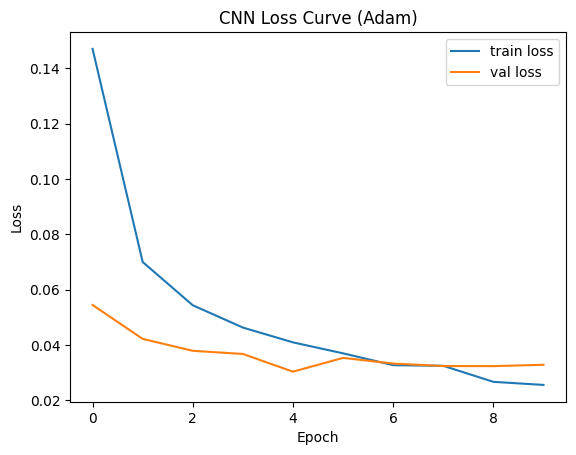

In [ ]:
plt.plot(history_adam.history['loss'], label='train loss')
plt.plot(history_adam.history['val_loss'], label='val loss')
plt.title('CNN Loss Curve (Adam)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
# This shows how the training and validation loss changes over epochs.

## Repeat for Other Optimizers
### ADADELTA

In [ ]:
#  cmppile the model of adalta optimizer
model.compile(optimizer='adadelta',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_adadelta = model.fit(x_train, y_train,
                             epochs=10,
                             batch_size=32,
                             validation_data=(x_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 71s 37ms/step - accuracy: 0.9931 - loss: 0.0215 - val_accuracy: 0.9913 - val_loss: 0.0327
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 38ms/step - accuracy: 0.9928 - loss: 0.0225 - val_accuracy: 0.9914 - val_loss: 0.0326
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 69s 37ms/step - accuracy: 0.9929 - loss: 0.0220 - val_accuracy: 0.9914 - val_loss: 0.0325
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 70s 37ms/step - accuracy: 0.9929 - loss: 0.0213 - val_accuracy: 0.9915 - val_loss: 0.0324
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 71s 38ms/step - accuracy: 0.9932 - loss: 0.0206 - val_accuracy: 0.9915 - val_loss: 0.0323
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 37ms/step - accuracy: 0.9937 - loss: 0.0203 - val_accuracy: 0.9915 - val_loss: 0.0322
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 70s 37ms/step - accuracy: 0.9933 - loss: 0.0207 - val_accuracy: 0.9914 - val_loss: 0.0321
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 72s 39ms/step - accuracy: 0.9930 -

## visulize its loss

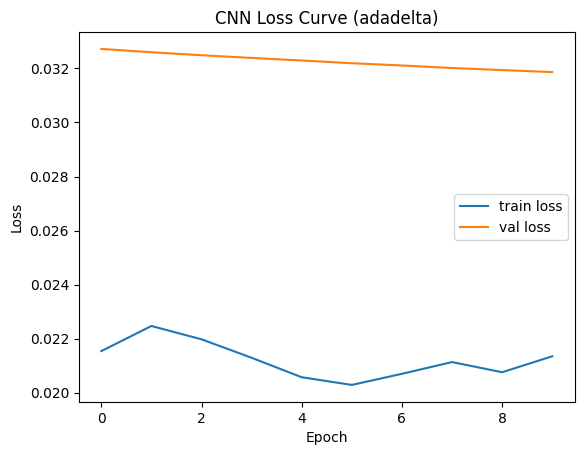

In [ ]:
plt.plot(history_adadelta.history['loss'], label='train loss')
plt.plot(history_adadelta.history['val_loss'], label='val loss')
plt.title('CNN Loss Curve (adadelta)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Stochastic Gradient Descent (SGD)

In [ ]:
model.compile(optimizer='sgd',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_sgd = model.fit(x_train, y_train,
                        epochs=10,
                        batch_size=32,
                        validation_data=(x_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 29ms/step - accuracy: 0.9945 - loss: 0.0169 - val_accuracy: 0.9919 - val_loss: 0.0278
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9943 - loss: 0.0170 - val_accuracy: 0.9924 - val_loss: 0.0285
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9951 - loss: 0.0143 - val_accuracy: 0.9919 - val_loss: 0.0288
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.9948 - loss: 0.0149 - val_accuracy: 0.9920 - val_loss: 0.0283
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9957 - loss: 0.0127 - val_accuracy: 0.9922 - val_loss: 0.0268
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9954 - loss: 0.0134 - val_accuracy: 0.9925 - val_loss: 0.0273
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.9952 - loss: 0.0141 - val_accuracy: 0.9919 - val_loss: 0.0277
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.9954 -

## visulize  sgd loss

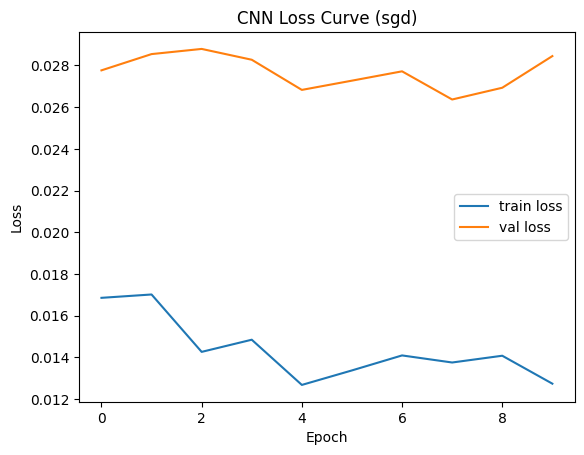

In [ ]:
plt.plot(history_sgd.history['loss'], label='train loss')
plt.plot(history_sgd.history['val_loss'], label='val loss')
plt.title('CNN Loss Curve (sgd)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Plot Comparison of Loss Curves

## i can also plot all 3 optimizers together:

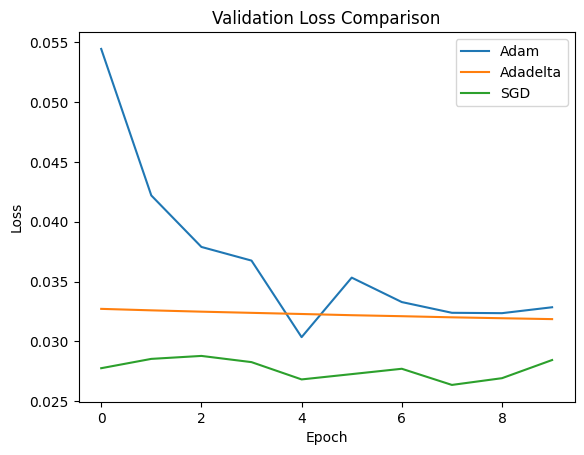

In [ ]:
plt.plot(history_adam.history['val_loss'], label='Adam')
plt.plot(history_adadelta.history['val_loss'], label='Adadelta')
plt.plot(history_sgd.history['val_loss'], label='SGD')
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## interpretaion for the validation loss graph
### 1 Adam
Observation:
Starts high (~0.045)
Drops quickly
Has fluctuations (up and down)
👉 Interpretation:
Adam learns fast initially but is less stable during training.

✔ Good early learning
❌ Slight instability (oscillation)

## 2 Adadelta (Orange Line)
#### Observation:
Almost a straight line (~0.032 → 0.031)
Very little change across epochs
### 👉 Interpretation:
Adadelta is very stable but learns slowly
✔ Very consistent
❌ No significant improvement
## 3 SGD (Green Line)
### Observation:

Starts low (~0.030)

Gradually decreases

Ends with the lowest loss (~0.028)

### 👉 Interpretation:

SGD shows steady improvement and best final performance

✔ Most stable improvement
✔ Lowest final validation loss

## step 6 Evaluate and Visualize Predictions

In [ ]:
# Evaluate the model using test data
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
# test_loss → final loss on unseen test images
# test_accuracy → final accuracy (percentage of correct predictions)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9919 - loss: 0.0284
Test Loss: 0.028446048498153687
Test Accuracy: 0.9919000267982483


## Make Predictions


In [ ]:

# Predict probabilities for first 10 test images
predictions = model.predict(x_test[:10])

# Convert probabilities to class labels
predicted_classes = np.argmax(predictions, axis=1)

# Actual labels
actual_classes = np.argmax(y_test[:10], axis=1)

print("Predicted:", predicted_classes)
print("Actual   :", actual_classes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
Predicted: [7 2 1 0 4 1 4 9 5 9]
Actual   : [7 2 1 0 4 1 4 9 5 9]


## Visualize Predictions

It’s nice to see the images with predicted labels:

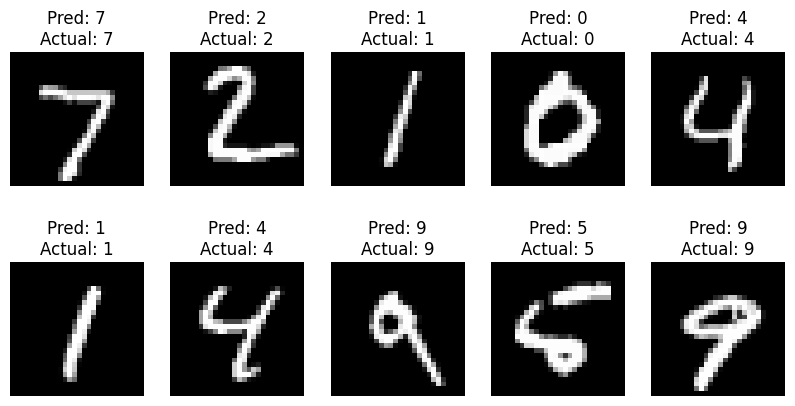

In [ ]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')  # reshape to 28x28 for display
    plt.title(f"Pred: {predicted_classes[i]}\nActual: {actual_classes[i]}")
    plt.axis('off')

plt.show()

## Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


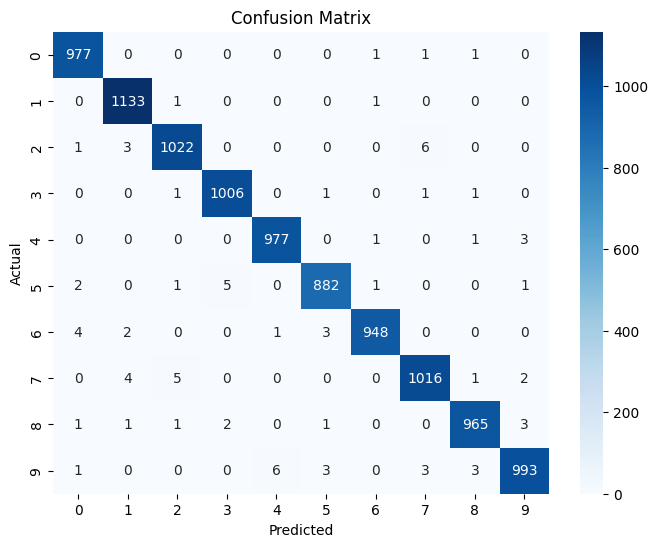

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(np.argmax(y_test, axis=1), np.argmax(model.predict(x_test), axis=1))

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## step 7 Save the Trained Model

In [ ]:
# Save the entire model (architecture + weights + optimizer state)
model.save("mnist_cnn_model.h5")

## Load the Model Later

In [ ]:
from tensorflow.keras.models import load_model

# Load the saved model
loaded_model = load_model("mnist_cnn_model.h5")

# Evaluate or predict as before
test_loss, test_accuracy = loaded_model.evaluate(x_test, y_test)
print("Loaded Model Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9919 - loss: 0.0284
Loaded Model Test Accuracy: 0.9919000267982483
